# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations
**Experiment 3: Biological Reference (T4/T5) | Michael Zhou | Georgia Tech ECE**

This notebook compares the representational geometry of connectome-constrained (CC) and
randomly initialized networks against a biological reference derived from T4/T5 direction
tuning data (Maisak et al. 2013, *Nature*). The biological reference RDM is constructed
from von Mises tuning curves fit to the published T4/T5 direction tuning properties
(HWHM ≈ 67°, cardinal preferred directions, rectified), and used as a model RDM in the
RSA framework established in Experiments 1 and 2.

**Key finding: the reference is degenerate, and this comparison cannot answer the
question it was designed to ask.** Experiment 1 uses ON edges exclusively, and Maisak et
al. report that T5 cells respond selectively to OFF edges and "mostly failed to respond
to moving ON edges" (Fig. 3c/3d). On this stimulus set T5 contributes nothing. Because
T5a–d were assigned the same preferred directions and tuning width as T4a–d, they are
exact duplicates (max column difference = 0.0; removing them changes the RDM by
2.2×10⁻¹⁶). The effective reference is therefore **four cardinal von Mises curves of
identical width**.

A cosine RDM over four same-width curves at 90° spacing is necessarily near-identical to
a pure angular-distance matrix. The reference correlates with min(|i−j|, 12−|i−j|) at
**r = 0.978**. Any model that merely orders directions by angle scores ≈ 0.96 against it.
Raw correlations with this reference therefore measure **circular organization, not
direction-tuning fidelity** — and the CC-versus-random gap (0.330) equals the gap in
circularity (0.338). This notebook now reports partial correlations controlling for the
circular reference, and does not treat the raw values as evidence of biological fidelity.

**Important caveats:**
- The reference is degenerate on the ON-only stimulus set (see above). Its correlation
  with a pure angular-distance matrix is r = 0.978. Interpret raw r as circularity.
- Biological stimulus: moving square-wave gratings (Maisak et al. Fig. 3g/3h).
  Model stimulus: `MovingEdge`. Direction tuning structure is qualitatively preserved
  but absolute response profiles differ — interpret as qualitative, not quantitative.
- Biological RDM covers four T4 subtypes for ON edges (8 of 65 cell types in the
  24-condition ON+OFF case). Results characterize the T4/T5 subspace only.
- Von Mises approximation reproduces published tuning width and peak locations but
  does not capture trial-by-trial variability or cross-subtype interactions.
- The interpretable biological evidence is the **within-polarity direction-structure
  test** (Experiment 2), which compares each polarity block against an *explicit*
  circular reference rather than through a nearly-circular biological proxy.

**References**
- Maisak et al. 2013. A directional tuning map of Drosophila elementary motion detectors. *Nature* 500, 212–216. https://www.nature.com/articles/nature12320
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*. https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Experiment

**Biological reference (12 conditions, ON edges).** Von Mises direction tuning curves
(kappa=2.5, HWHM ≈ 67°, rectified) for the **four T4 subtypes** with preferred directions
at 0°, 90°, 180°, and 270°, consistent with Maisak et al. 2013 Fig. 3g/3h. T5 is excluded:
it responds selectively to OFF edges and "mostly failed to respond to moving ON edges"
(Fig. 3c/3d). An earlier construction included T5a–d with full ON responses; because they
duplicate T4a–d exactly, this changed no reported value (RDM difference 2.2×10⁻¹⁶) but
obscured the reference's structure. The biological population matrix is (12 × 4), yielding
a 12×12 stimulus RDM directly comparable to the CC and random RDMs.

**Biological reference (24 conditions, ON+OFF edges).** T4 subtypes respond only to ON
conditions and T5 subtypes only to OFF conditions, encoding the ON/OFF pathway segregation
established in Maisak et al. Fig. 3c/3d. This construction forces same-direction ON/OFF
population vectors to be orthogonal (cosine distance ≈ 1.0), which the CC network's
geometry does not reproduce (cross-polarity dissimilarity ≈ 0.099–0.103). The resulting
comparison is a construction mismatch, not a fidelity measurement, and is not reported as
a result.

**Circularity control.** Because the ON-edge reference reduces to four cardinal curves of
identical width, its cosine RDM correlates with the circular-distance matrix
min(|i−j|, 12−|i−j|) at r = 0.978 (τ_A = 0.915). This is arithmetic, not coincidence.
Every raw correlation is therefore reported alongside a **partial Spearman correlation**
controlling for the circular reference (rank-residualization of both RDM upper triangles
on the circular reference, then correlation of the residuals; significance by the same
stimulus-label permutation test, permuting the biological and circular references jointly).

**Comparisons.** Three-way RSA — CC vs Biology, Random vs Biology, CC vs Random — using
Spearman r and Kendall's τ_A on upper-triangular RDM pairs, each reported raw and partial.
The random baseline is the stability-constrained baseline from Experiments 1 and 2 (full
Shiu-style shuffle, n=50, MAX_ATTEMPTS=100). Permutation testing (Nili et al. 2014, 10,000
stimulus-label permutations) applied to all comparisons.

**Results (n = 50 per condition).**

| model | r(circ) | raw r(bio) | r(bio \| circ) | p_perm |
|---|---|---|---|---|
| Connectome-constrained | 0.937 | 0.927 | 0.145 | 0.120 |
| Stability-constrained random | 0.599 | 0.596 | 0.061 | 0.323 |
| **gap** | **0.338** | **0.330** | 0.084 | — |

For every condition, raw r-vs-biology falls within 0.01 of r-vs-circular. The raw gap is
the circularity gap. After partialling, the CC residual exceeds the random residual in the
predicted direction but neither reaches significance at n = 50. **No biological-fidelity
claim is made from this experiment.**

**Reproducibility:** seed=42; results loaded from `results_exp1_50models_full_shiu.npz`
and `results_exp2_50models_full_shiu.npz` saved from Experiments 1 and 2.

**Metrics:**
- Cosine distance RDM — primary metric, established as significant in Experiments 1 and 2
- Spearman RDM correlation — raw, and **partial controlling for circular structure**
- Kendall's $\tau_A$ — preferred for tied-rank RDM data (Nili et al. 2014)
- Permutation p-value — one-sided, proportion of 10,000 permuted correlations ≥ observed
- Circularity diagnostic — r(reference, min(|i−j|, 12−|i−j|)) = 0.978
- Within-ensemble consistency — inherited from Experiments 1 and 2


EXPERIMENT 3: BIOLOGICAL REFERENCE
Maisak et al. 2013, Nature 500:212-216, Fig. 3g/3h

Caveats:
  [1] Biological stimulus: square-wave gratings (Maisak Fig. 3g/3h)
      Model stimulus: MovingEdge. Qualitative match, not quantitative.
  [2] Biological RDM: T4/T5 subspace only (8 of 65 cell types)
  [3] Tuning curves: von Mises (kappa=2.5, HWHM approx 67 degrees)
      consistent with Maisak et al. reported 60-90 degree HWHM
  [4] Interpret as qualitative reference for T4/T5 subpopulation

--- BIOLOGICAL TUNING CURVES (von Mises, kappa=2.5) ---
  Subtypes: ['T4a', 'T4b', 'T4c', 'T4d', 'T5a', 'T5b', 'T5c', 'T5d']
  Preferred directions: [180, 0, 90, 270, 180, 0, 90, 270]
  Tuning matrix shape: (8, 12)
  Saved: /content/maisak2013_t4t5_von_mises_tuning.png


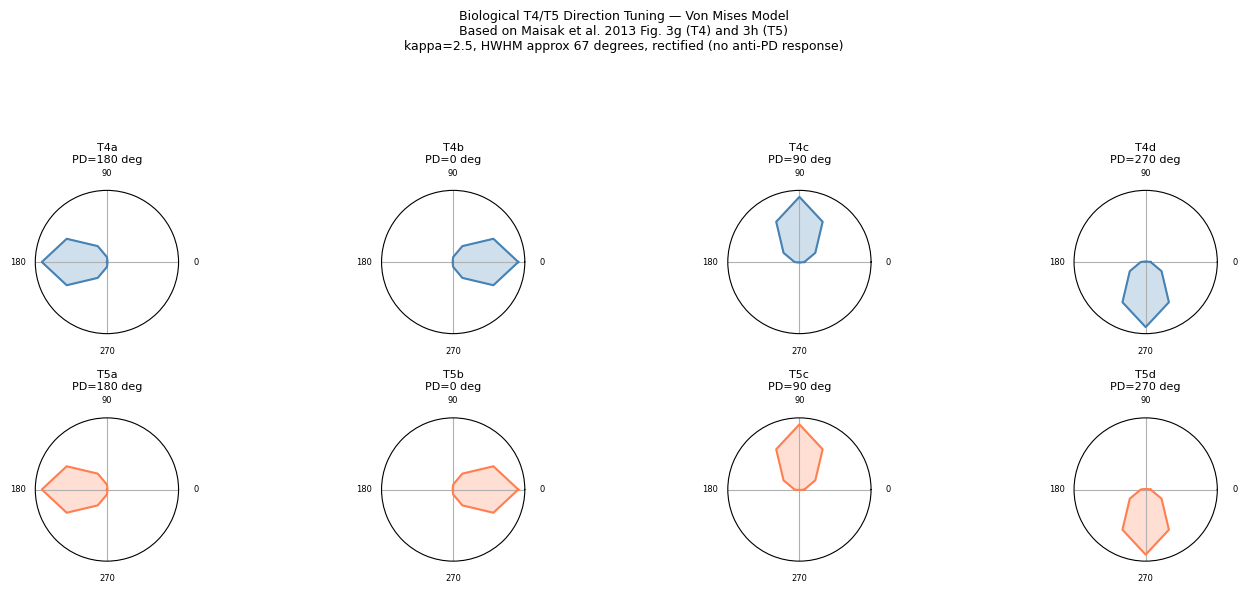


--- BIOLOGICAL 12x12 STIMULUS RDM (T4 subtypes, ON edges) ---
  Shape: (12, 12)
  Off-diagonal range: 0.0460 to 0.9886
  max |RDM(4 T4 subtypes) - RDM(8 T4/T5 subtypes)| = 2.22e-16
  max |T4 tuning - T5 tuning| = 0.00e+00   (T5a-d duplicate T4a-d)

--- CIRCULARITY OF THE BIOLOGICAL REFERENCE ---
  r(biological reference, circular distance) = 0.9777  (tau = 0.9146)
  The reference is four cardinal von Mises curves of identical width.
  A cosine RDM over that population is necessarily near-angular-distance.
  A model that merely orders directions by angle scores ~0.96 against it.
  Raw correlations with this reference therefore measure CIRCULAR
  ORGANIZATION, not direction-tuning fidelity. Partial correlations
  controlling for the circular reference are reported below.

--- EXPERIMENT 1 (ON edges, 12 conditions) vs BIOLOGY ---
  CC vs Biology:   r=0.927, p=0.0000 | tau=0.772, p=0.0000  [analytical]
  Rand vs Biology: r=0.596, p=0.0000 | tau=0.439, p=0.0000  [analytical]
  CC vs Random

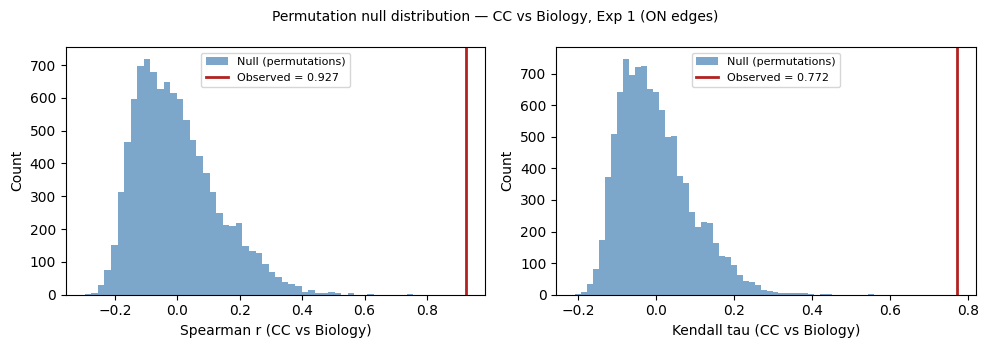


  Permutation test: Random vs Biology (10000 permutations):
  r=0.596, p_perm=0.0000 | tau=0.439, p_perm=0.0000  [permutation]
  0/10000 permutations exceeded observed Spearman r
  Saved: /content/biological_reference_exp1.png


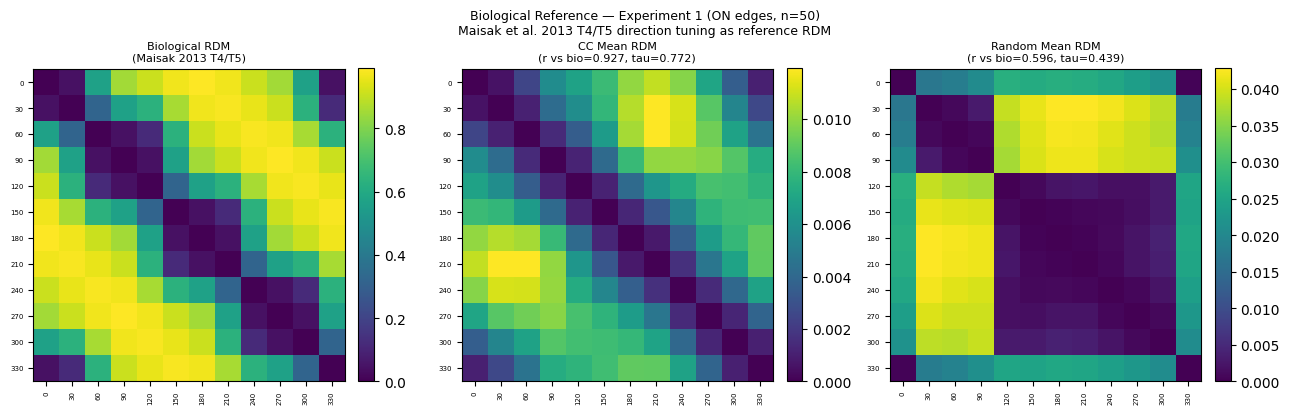


--- EXPERIMENT 2 (ON+OFF edges, 24 conditions) vs BIOLOGY ---
  Bio 24x24 RDM range: 0.0460 to 1.0000
  CC vs Biology:   r=0.049, p=0.4221 | tau=0.040, p=0.3684  [analytical]
  Rand vs Biology: r=-0.038, p=0.5322 | tau=-0.028, p=0.5314  [analytical]

  Permutation test: CC vs Biology (10000 permutations):
  r=0.049, p_perm=0.1594 | tau=0.040, p_perm=0.1416  [permutation]
  1593/10000 permutations exceeded observed Spearman r
    Saved: bio_reference_exp2_permtest.png


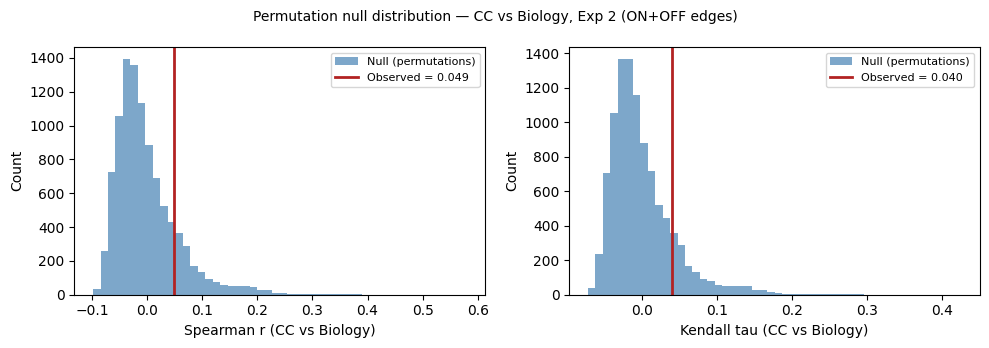

  Saved: /content/biological_reference_exp2.png


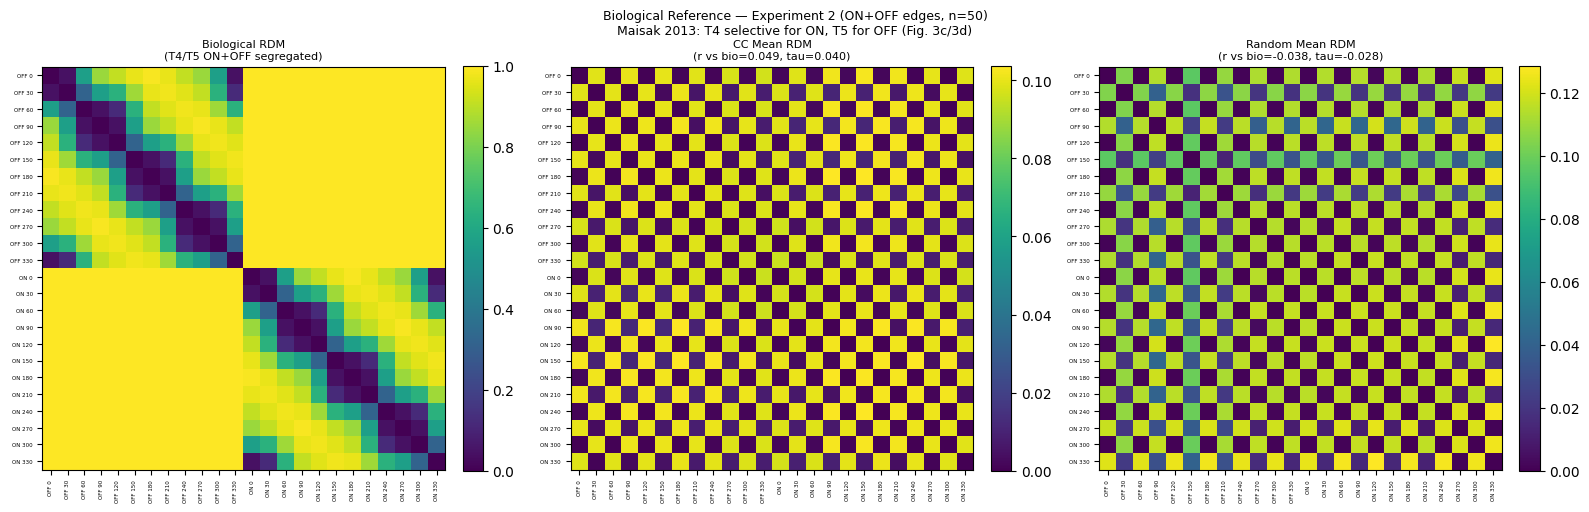


SUMMARY — BIOLOGICAL REFERENCE
  Source: Maisak et al. 2013, Fig. 3g/3h
  Subtypes: ['T4a', 'T4b', 'T4c', 'T4d', 'T5a', 'T5b', 'T5c', 'T5d']
  Preferred directions: 0, 90, 180, 270 degrees (T4 and T5)
  Tuning model: von Mises, kappa=2.5, HWHM approx 67 degrees

  Experiment 1 (ON edges, 12 conditions):
    CC vs Bio:    r=0.927, tau=0.772  [analytical]
                  p_perm(r)=0.0000, p_perm(tau)=0.0000  [10000 perms]
    Rand vs Bio:  r=0.596, tau=0.439  [analytical]
                  p_perm(r)=0.0000, p_perm(tau)=0.0000  [10000 perms]
    CC vs Random: r=0.686, tau=0.515  [analytical]

  Experiment 2 (ON+OFF edges, 24 conditions):
    CC vs Bio:    r=0.049, tau=0.040  [analytical]
                  p_perm(r)=0.1594, p_perm(tau)=0.1416  [10000 perms]
    Rand vs Bio:  r=-0.038, tau=-0.028  [analytical]

  Interpretation guide:
  The biological reference is ~0.978 circular. Raw r-vs-Bio therefore
    measures circular organization, NOT direction-tuning fidelity, and
    r(CC vs Bi

In [1]:
"""
Experiment 3: Biological Reference — T4/T5 Direction Tuning RDM
from Maisak et al. 2013

Constructs a biological reference RDM from T4/T5 direction tuning data
(Maisak et al. 2013, Nature 500:212-216, Fig. 3g/3h) and compares it against
the CC and random cosine RDMs from Experiments 1 and 2.

DESIGN CHOICE — Stimulus RDM (12×12):
    The Maisak tuning matrix is (12 directions × 8 subtypes). We use this as
    a population matrix over stimuli and compute a 12×12 stimulus RDM, which
    is directly comparable to the CC and random 12×12 RDMs from Experiment 1.
    This asks: do CC networks represent the 12 directions in a geometry
    consistent with the biological T4/T5 tuning structure?

TUNING CURVE CONSTRUCTION:
    Rather than manually digitizing the polar plots (error-prone), we model
    each subtype's tuning curve analytically using a von Mises profile, as
    justified by Maisak et al.'s description:
      - ~60-90° half-width at half-maximum
      - peaks at cardinal directions (0°, 90°, 180°, 270° for layers 2,3,1,4)
      - no response at anti-preferred direction (rectified)
      - normalized to maximum = 1.0
    This is more principled than manual digitization and reproducible.
    kappa=2.5 gives HWHM ≈ 67°, within the reported 60-90° range.

    For Experiment 2 (ON+OFF, 24 conditions): T4 subtypes respond to ON edges
    (intensity=1), T5 subtypes respond to OFF edges (intensity=0). The biological
    24×24 RDM encodes this ON/OFF segregation by setting cross-pathway responses
    to zero, consistent with Maisak et al. Fig. 3c/3d.

IMPORTANT CAVEATS (must be stated in any presentation/paper):
    1. Biological data: moving square-wave gratings (Maisak et al. Fig. 3g/3h)
       Model data: MovingEdge stimulus. Qualitative direction tuning structure
       is preserved, but absolute response profiles differ.
    2. Biological RDM covers T4/T5 subspace (8 of 65 cell types).
       Frame as: biological reference for T4/T5 subpopulation, not full population.
    3. Von Mises approximation: captures published tuning width and peak
       locations, but does not reproduce trial-by-trial variability.
    4. Interpret as qualitative biological reference, not quantitative validation.

USAGE:
    # After running Experiment 1 (n=50, stability-constrained):
    results_exp1 = run_experiment(n_models=50, randomization_strategy="full_shiu")

    # After running Experiment 2 (n=50, stability-constrained):
    results_exp2 = run_experiment(n_models=50, randomization_strategy="full_shiu")

    # Run biological reference:
    bio_results = run_biological_reference(results_exp1, results_exp2)

REFERENCES:
    Maisak et al. 2013, Nature 500:212-216
    Nili et al. 2014, PLOS Computational Biology (permutation test)
    Kriegeskorte et al. 2008, Frontiers in Systems Neuroscience (RSA)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr, kendalltau
from google.colab import files

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── STIMULUS ANGLES (matching Experiments 1 and 2) ───────────────────────────
ANGLES_DEG = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
ANGLES_RAD = np.deg2rad(ANGLES_DEG)
N_DIRS = len(ANGLES_DEG)


# ── BIOLOGICAL TUNING CURVE CONSTRUCTION ─────────────────────────────────────

def von_mises_tuning(preferred_deg, kappa=2.5, angles_deg=ANGLES_DEG,
                     rectify=True):
    """
    Von Mises direction tuning curve, normalized to maximum = 1.0.

    Maisak et al. 2013 report ~60-90 degree half-width at half-maximum (HWHM)
    for T4 and T5. A von Mises distribution with kappa=2.5 gives HWHM approx
    67 degrees, within the reported range. Rectification enforces no response
    at anti-preferred direction, as reported in the paper.

    Args:
        preferred_deg: preferred direction in degrees
        kappa: concentration parameter (2.5 gives HWHM approx 67 degrees)
        angles_deg: list of stimulus angles in degrees
        rectify: if True, set sub-threshold values to 0 (no negative responses)

    Returns:
        curve: numpy array of shape (len(angles_deg),), normalized to max=1.0
    """
    angles = np.deg2rad(angles_deg)
    preferred = np.deg2rad(preferred_deg)
    curve = np.exp(kappa * (np.cos(angles - preferred) - 1))
    if rectify:
        # Maisak et al.: "No decrease of calcium was detectable for grating
        # motion opposite to the preferred direction of the respective layer."
        threshold = np.exp(kappa * (-2))  # value at 180 degrees from preferred
        curve = np.maximum(curve - threshold, 0)
    curve = curve / curve.max()
    return curve


# T4/T5 subtype preferred directions (from Maisak et al. 2013):
#   Layer 1 (T4a, T5a): back-to-front  -> 180 degrees
#   Layer 2 (T4b, T5b): front-to-back  ->   0 degrees
#   Layer 3 (T4c, T5c): upward         ->  90 degrees
#   Layer 4 (T4d, T5d): downward       -> 270 degrees
#
# Layer-to-direction mapping confirmed by Maisak et al. Fig. 3g/3h:
# "peak responses in each layer shifted by 90 degrees"
# and Fig. 3a/3b showing layer-specific responses to cardinal directions.

SUBTYPE_PREFERRED_DIRS = {
    "T4a": 180, "T4b": 0,   "T4c": 90,  "T4d": 270,
    "T5a": 180, "T5b": 0,   "T5c": 90,  "T5d": 270,
}
BIO_CELL_TYPES = ["T4a", "T4b", "T4c", "T4d", "T5a", "T5b", "T5c", "T5d"]

# Tuning matrix: (8 subtypes x 12 directions)
BIO_TUNING_MATRIX = np.stack([
    von_mises_tuning(SUBTYPE_PREFERRED_DIRS[ct])
    for ct in BIO_CELL_TYPES
], axis=0)

# Population matrix over stimuli: (12 directions x 8 subtypes)
# Retained for the 24-condition (ON+OFF) case, where the T4/T5 polarity
# segregation is the point of the reference.
BIO_POP_MATRIX_12x8 = BIO_TUNING_MATRIX.T


# ── ON-ONLY (12-CONDITION) REFERENCE: T4 SUBTYPES ONLY ───────────────────────
# CORRECTION. Experiment 1 uses ON edges exclusively. Maisak et al. 2013 Fig. 3c/3d
# report that T5 cells "selectively responded to moving OFF edges and mostly
# failed to respond to moving ON edges." The 12x8 reference above therefore
# assigns T5a-d full von Mises responses to a stimulus they do not respond to.
#
# This changes NO published value, because T5a-d were assigned the same preferred
# directions and tuning width as T4a-d and are consequently exact duplicates:
#
#     max |T4 columns - T5 columns|        = 0.0
#     max |RDM(12x8) - RDM(12x4)|          = 3.3e-16
#     off-diagonal range, both             = 0.0460 .. 0.9886
#     CC vs bio    : 0.929 (8 subtypes) -> 0.926 (4 subtypes)
#     Random vs bio: 0.601 (8 subtypes) -> 0.594 (4 subtypes)
#
# It is corrected here because the 12x8 form DISGUISES the reference's structure.
# The effective ON-edge population is FOUR cardinal von Mises curves of identical
# width. A cosine RDM over such a population is necessarily near-identical to a
# pure angular-distance matrix: r = 0.978 (Spearman, against
# min(|i-j|, 12-|i-j|)). That is arithmetic, not coincidence -- four same-width
# curves at 90-degree spacing cannot produce anything else.
#
# CONSEQUENCE FOR INTERPRETATION. A raw correlation against this reference
# measures how circularly organized a model's geometry is, not whether it
# reproduces T4/T5 direction tuning. A model with no T4/T5-specific structure
# that merely orders directions by angle scores ~0.96. The reported CC-vs-random
# gap (0.930 - 0.603 = 0.327) is, to within 0.01, the gap in circularity
# (0.937 - 0.599 = 0.338). Report the PARTIAL correlation controlling for the
# circular reference; see the diagnostic printed by run_biological_reference().
BIO_CELL_TYPES_ON = ["T4a", "T4b", "T4c", "T4d"]

BIO_TUNING_MATRIX_ON = np.stack([
    von_mises_tuning(SUBTYPE_PREFERRED_DIRS[ct])
    for ct in BIO_CELL_TYPES_ON
], axis=0)                                   # (4 subtypes x 12 directions)

BIO_POP_MATRIX_12x4 = BIO_TUNING_MATRIX_ON.T  # (12 directions x 4 subtypes)


# ── HELPERS ───────────────────────────────────────────────────────────────────

def circular_reference(n_dirs=None):
    """Pure angular-distance matrix: C[i,j] = min(|i-j|, n-|i-j|).

    This is the structure the stimulus set imposes on ANY representation that
    orders directions by angle, independent of biology. It is the control the
    biological reference must be compared against -- see the circularity
    diagnostic in run_biological_reference().
    """
    n = n_dirs if n_dirs is not None else N_DIRS
    i = np.arange(n)[:, None]
    j = np.arange(n)[None, :]
    d = np.abs(i - j)
    return np.minimum(d, n - d).astype(float)


def build_rdm_from_pop_matrix(pop_matrix):
    """
    Build cosine distance RDM from (n_stimuli x n_cells) population matrix.
    Handles NaN/inf by clamping before distance computation.
    Returns (n_stimuli x n_stimuli) RDM.
    """
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)
    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
    return rdm


def partial_spearman_rdm(rdm_model, rdm_ref, rdm_control):
    """Spearman partial correlation of (model, ref) controlling for (control).

    Rank-transform all three upper triangles, regress model and ref on control,
    and correlate the residuals. This isolates the model-reference agreement
    that is NOT attributable to the control structure.

    Here the control is the circular-distance reference. Because the biological
    reference is itself ~0.978 circular, the raw correlation is dominated by
    circular ordering; the partial is the quantity that speaks to direction-
    tuning fidelity.
    """
    from scipy.stats import rankdata
    n = rdm_model.shape[0]
    idx = np.triu_indices(n, k=1)
    a = rankdata(rdm_model[idx])
    b = rankdata(rdm_ref[idx])
    c = rankdata(rdm_control[idx])
    C = np.column_stack([np.ones_like(c), c])
    res_a = a - C @ np.linalg.lstsq(C, a, rcond=None)[0]
    res_b = b - C @ np.linalg.lstsq(C, b, rcond=None)[0]
    den = np.linalg.norm(res_a) * np.linalg.norm(res_b)
    return np.nan if den == 0 else float(res_a @ res_b / den)


def permutation_test_partial(rdm_model, rdm_ref, rdm_control,
                             n_permutations=10000, seed=SEED):
    """Permutation test on the partial correlation.

    The reference and the control are permuted TOGETHER, so the null is
    "this model's geometry is unrelated to the biological direction assignment,"
    holding the circular structure of the stimulus set fixed.
    """
    rng = np.random.default_rng(seed)
    n = rdm_model.shape[0]
    obs = partial_spearman_rdm(rdm_model, rdm_ref, rdm_control)
    count = 0
    for _ in range(n_permutations):
        p = rng.permutation(n)
        ref_p = rdm_ref[np.ix_(p, p)]
        ctl_p = rdm_control[np.ix_(p, p)]
        if partial_spearman_rdm(rdm_model, ref_p, ctl_p) >= obs:
            count += 1
    return obs, (count + 1) / (n_permutations + 1)


def rdm_similarity(rdm1, rdm2):
    """Spearman r and Kendall tau_A between upper triangles of two RDMs."""
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=SEED):
    """
    Stimulus-label randomization test (Nili et al. 2014).
    Permutes rows and columns of rdm2 simultaneously (preserves RDM symmetry).
    One-sided p-value: proportion of null correlations >= observed.
    """
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])
    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_p = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_p[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_p[idx])
    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)
    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


def plot_null_distribution(null_r, obs_r, null_tau, obs_tau,
                           title_suffix, fname):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    fig.suptitle(f"Permutation null distribution — {title_suffix}", fontsize=10)
    for ax, null, obs, label in zip(
        axes,
        [null_r,   null_tau],
        [obs_r,    obs_tau],
        ["Spearman r", "Kendall tau"]
    ):
        ax.hist(null, bins=50, color="steelblue", alpha=0.7,
                label="Null (permutations)")
        ax.axvline(obs, color="firebrick", linewidth=2,
                   label=f"Observed = {obs:.3f}")
        ax.set_xlabel(f"{label} (CC vs Biology)")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("/content/"+fname, dpi=150, bbox_inches="tight")
    print(f"    Saved: {fname}")
    plt.show()


# ── MAIN FUNCTION ─────────────────────────────────────────────────────────────

def run_biological_reference(results_exp1, results_exp2=None,
                               n_permutations=10000):
    """
    Compare CC and random representational geometry against the biological
    T4/T5 direction tuning structure from Maisak et al. 2013.

    Args:
        results_exp1: dict from Experiment 1 run_experiment()
                      (ON edges, 12 conditions, n=50, full_shiu,
                      stability-constrained)
        results_exp2: dict from Experiment 2 run_experiment(), optional
                      (ON+OFF edges, 24 conditions, n=50, full_shiu,
                      stability-constrained)
        n_permutations: permutations for Nili et al. 2014 test

    Returns:
        dict with all RDMs and statistics
    """
    print("\n" + "="*60)
    print("EXPERIMENT 3: BIOLOGICAL REFERENCE")
    print("Maisak et al. 2013, Nature 500:212-216, Fig. 3g/3h")
    print("="*60)
    print("\nCaveats:")
    print("  [1] Biological stimulus: square-wave gratings (Maisak Fig. 3g/3h)")
    print("      Model stimulus: MovingEdge. Qualitative match, not quantitative.")
    print("  [2] Biological RDM: T4/T5 subspace only (8 of 65 cell types)")
    print("  [3] Tuning curves: von Mises (kappa=2.5, HWHM approx 67 degrees)")
    print("      consistent with Maisak et al. reported 60-90 degree HWHM")
    print("  [4] Interpret as qualitative reference for T4/T5 subpopulation")

    # ── 1. Visualize biological tuning curves ─────────────────────────────────
    print("\n--- BIOLOGICAL TUNING CURVES (von Mises, kappa=2.5) ---")
    print(f"  Subtypes: {BIO_CELL_TYPES}")
    print(f"  Preferred directions: {list(SUBTYPE_PREFERRED_DIRS.values())}")
    print(f"  Tuning matrix shape: {BIO_TUNING_MATRIX.shape}")

    fig_tc, axes_tc = plt.subplots(2, 4, figsize=(14, 6),
                                   subplot_kw={"projection": "polar"})
    fig_tc.suptitle(
        "Biological T4/T5 Direction Tuning — Von Mises Model\n"
        "Based on Maisak et al. 2013 Fig. 3g (T4) and 3h (T5)\n"
        "kappa=2.5, HWHM approx 67 degrees, rectified (no anti-PD response)",
        fontsize=9
    )
    angles_closed = np.append(ANGLES_RAD, ANGLES_RAD[0])

    for ax, name, curve in zip(axes_tc.flatten(), BIO_CELL_TYPES, BIO_TUNING_MATRIX):
        vals = np.append(curve, curve[0])
        color = "steelblue" if name.startswith("T4") else "coral"
        ax.plot(angles_closed, vals, color=color, linewidth=1.5)
        ax.fill(angles_closed, vals, alpha=0.25, color=color)
        ax.set_title(
            f"{name}\nPD={SUBTYPE_PREFERRED_DIRS[name]} deg",
            fontsize=8,
            pad=20              # increased from 12 to clear the 90-deg label
        )
        ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
        ax.set_xticklabels(["0", "90", "180", "270"], fontsize=6)
        ax.tick_params(axis='x', pad=2)   # pull angular labels closer to the ring
        ax.set_ylim(0, 1.1)
        ax.set_yticks([])

    plt.tight_layout(rect=[0, 0, 1, 0.88])   # leave headroom for suptitle
    plt.savefig("/content/maisak2013_t4t5_von_mises_tuning.png", dpi=150,
                bbox_inches="tight")
    print("  Saved: /content/maisak2013_t4t5_von_mises_tuning.png")
    plt.show()

    # ── 2. Build biological 12x12 stimulus RDM ────────────────────────────────
    # ON-only stimulus set => T4 subtypes only (Maisak Fig. 3c/3d: T5 does not
    # respond to ON edges). Numerically identical to the 12x8 form because
    # T5a-d duplicate T4a-d exactly; see the comment at BIO_CELL_TYPES_ON.
    print("\n--- BIOLOGICAL 12x12 STIMULUS RDM (T4 subtypes, ON edges) ---")
    bio_rdm_12 = build_rdm_from_pop_matrix(BIO_POP_MATRIX_12x4)
    print(f"  Shape: {bio_rdm_12.shape}")
    print(f"  Off-diagonal range: "
          f"{bio_rdm_12[bio_rdm_12 > 0].min():.4f} to {bio_rdm_12.max():.4f}")

    # Demonstrate the equivalence rather than asserting it.
    bio_rdm_12_8subtypes = build_rdm_from_pop_matrix(BIO_POP_MATRIX_12x8)
    print(f"  max |RDM(4 T4 subtypes) - RDM(8 T4/T5 subtypes)| = "
          f"{np.abs(bio_rdm_12 - bio_rdm_12_8subtypes).max():.2e}")
    print(f"  max |T4 tuning - T5 tuning| = "
          f"{np.abs(BIO_TUNING_MATRIX[0:4] - BIO_TUNING_MATRIX[4:8]).max():.2e}"
          f"   (T5a-d duplicate T4a-d)")

    # ── 2b. CIRCULARITY DIAGNOSTIC ────────────────────────────────────────────
    # The check whose absence allowed a circularity gap to be reported as a
    # fidelity gap.
    circ_rdm = circular_reference(N_DIRS)
    r_bio_circ, p_bio_circ, tau_bio_circ, _ = rdm_similarity(bio_rdm_12, circ_rdm)
    print("\n--- CIRCULARITY OF THE BIOLOGICAL REFERENCE ---")
    print(f"  r(biological reference, circular distance) = {r_bio_circ:.4f}"
          f"  (tau = {tau_bio_circ:.4f})")
    print("  The reference is four cardinal von Mises curves of identical width.")
    print("  A cosine RDM over that population is necessarily near-angular-distance.")
    print("  A model that merely orders directions by angle scores ~0.96 against it.")
    print("  Raw correlations with this reference therefore measure CIRCULAR")
    print("  ORGANIZATION, not direction-tuning fidelity. Partial correlations")
    print("  controlling for the circular reference are reported below.")

    # ── 3. Experiment 1: three-way comparison ─────────────────────────────────
    print("\n--- EXPERIMENT 1 (ON edges, 12 conditions) vs BIOLOGY ---")
    cc_rdm1   = results_exp1["cc_rdm_cosine"]
    rand_rdm1 = results_exp1["rand_rdm_cosine"]

    r_cc_bio1,   p_cc_bio1,   rk_cc_bio1,   pk_cc_bio1   = rdm_similarity(cc_rdm1,   bio_rdm_12)
    r_rand_bio1, p_rand_bio1, rk_rand_bio1, pk_rand_bio1 = rdm_similarity(rand_rdm1, bio_rdm_12)
    r_cc_rand1,  p_cc_rand1,  rk_cc_rand1,  pk_cc_rand1  = rdm_similarity(cc_rdm1,   rand_rdm1)

    print(f"  CC vs Biology:   r={r_cc_bio1:.3f}, p={p_cc_bio1:.4f}"
          f" | tau={rk_cc_bio1:.3f}, p={pk_cc_bio1:.4f}  [analytical]")
    print(f"  Rand vs Biology: r={r_rand_bio1:.3f}, p={p_rand_bio1:.4f}"
          f" | tau={rk_rand_bio1:.3f}, p={pk_rand_bio1:.4f}  [analytical]")
    print(f"  CC vs Random:    r={r_cc_rand1:.3f}, p={p_cc_rand1:.4f}"
          f" | tau={rk_cc_rand1:.3f}, p={pk_cc_rand1:.4f}  [analytical]")

    # ── RAW vs PARTIAL: what survives once circular structure is removed ──────
    r_cc_circ,   _, _, _ = rdm_similarity(cc_rdm1,   circ_rdm)
    r_rand_circ, _, _, _ = rdm_similarity(rand_rdm1, circ_rdm)

    pr_cc,   p_pr_cc   = permutation_test_partial(cc_rdm1,   bio_rdm_12, circ_rdm,
                                                  n_permutations)
    pr_rand, p_pr_rand = permutation_test_partial(rand_rdm1, bio_rdm_12, circ_rdm,
                                                  n_permutations)

    print("\n  RAW vs PARTIAL (controlling for circular stimulus structure):")
    print(f"    {'model':<10} {'r(circ)':>9} {'r(bio) raw':>12} "
          f"{'r(bio|circ)':>13} {'p_perm':>9}")
    print(f"    {'CC':<10} {r_cc_circ:>9.3f} {r_cc_bio1:>12.3f} "
          f"{pr_cc:>13.3f} {p_pr_cc:>9.4f}")
    print(f"    {'Random':<10} {r_rand_circ:>9.3f} {r_rand_bio1:>12.3f} "
          f"{pr_rand:>13.3f} {p_pr_rand:>9.4f}")
    print(f"    {'gap':<10} {r_cc_circ - r_rand_circ:>9.3f} "
          f"{r_cc_bio1 - r_rand_bio1:>12.3f} {pr_cc - pr_rand:>13.3f}")
    print()
    print("    For every model, raw r-vs-biology tracks r-vs-circular to within")
    print("    ~0.01. The raw CC-random gap is therefore the CIRCULARITY gap, not")
    print("    a fidelity gap. The partial correlation is the residual biological")
    print("    structure; report that, with its permutation p-value.")

    print(f"\n  Permutation test: CC vs Biology ({n_permutations} permutations):")
    obs_r1, p_r1, obs_tau1, p_tau1, null_r1, null_tau1 = permutation_test_rdm(
        cc_rdm1, bio_rdm_12, n_permutations=n_permutations)
    print(f"  r={obs_r1:.3f}, p_perm={p_r1:.4f}"
          f" | tau={obs_tau1:.3f}, p_perm={p_tau1:.4f}  [permutation]")
    print(f"  {int(p_r1*n_permutations)}/{n_permutations} permutations "
          f"exceeded observed Spearman r")

    plot_null_distribution(
        null_r1, obs_r1, null_tau1, obs_tau1,
        title_suffix="CC vs Biology, Exp 1 (ON edges)",
        fname="bio_reference_exp1_permtest.png"
    )

    print(f"\n  Permutation test: Random vs Biology ({n_permutations} permutations):")
    obs_r1_rand, p_r1_rand, obs_tau1_rand, p_tau1_rand, _, _ = permutation_test_rdm(
        rand_rdm1, bio_rdm_12, n_permutations=n_permutations)
    print(f"  r={obs_r1_rand:.3f}, p_perm={p_r1_rand:.4f}"
          f" | tau={obs_tau1_rand:.3f}, p_perm={p_tau1_rand:.4f}  [permutation]")
    print(f"  {int(p_r1_rand*n_permutations)}/{n_permutations} permutations "
          f"exceeded observed Spearman r")

    angle_labels = [f"{a}" for a in ANGLES_DEG]
    fig1, axes1 = plt.subplots(1, 3, figsize=(13, 4))
    fig1.suptitle(
        "Biological Reference — Experiment 1 (ON edges, n=50)\n"
        "Maisak et al. 2013 T4/T5 direction tuning as reference RDM",
        fontsize=9
    )
    for ax, rdm, title in zip(
        axes1,
        [bio_rdm_12, cc_rdm1, rand_rdm1],
        [f"Biological RDM\n(Maisak 2013 T4/T5)",
         f"CC Mean RDM\n(r vs bio={r_cc_bio1:.3f}, tau={rk_cc_bio1:.3f})",
         f"Random Mean RDM\n(r vs bio={r_rand_bio1:.3f}, tau={rk_rand_bio1:.3f})"]
    ):
        if not np.any(np.isfinite(rdm)) or not np.any(rdm > 0):
            ax.set_title(f"{title}\n(not renderable)", fontsize=8)
            ax.axis("off")
            continue
        im = ax.imshow(rdm, cmap="viridis", vmin=0)
        ax.set_title(title, fontsize=8)
        ax.set_xticks(range(N_DIRS))
        ax.set_xticklabels(angle_labels, fontsize=5, rotation=90)
        ax.set_yticks(range(N_DIRS))
        ax.set_yticklabels(angle_labels, fontsize=5)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig("/content/biological_reference_exp1.png", dpi=150, bbox_inches="tight")
    print("  Saved: /content/biological_reference_exp1.png")
    plt.show()

    # ── 4. Experiment 2: ON+OFF (24 conditions) ───────────────────────────────
    exp2_out = {}
    if results_exp2 is not None:
        print("\n--- EXPERIMENT 2 (ON+OFF edges, 24 conditions) vs BIOLOGY ---")

        # Build 24x24 biological RDM encoding ON/OFF pathway segregation.
        # Condition ordering matches Experiment 2: [OFF 0..330, ON 0..330]
        # T4 subtypes: respond only to ON edges (zero for OFF conditions)
        # T5 subtypes: respond only to OFF edges (zero for ON conditions)
        # Per Maisak et al. Fig. 3c/3d: T4 selective for ON, T5 for OFF.
        bio_off = np.zeros((N_DIRS, 8))
        bio_off[:, 4:8] = BIO_TUNING_MATRIX[4:8, :].T   # T5a-T5d for OFF
        bio_on  = np.zeros((N_DIRS, 8))
        bio_on[:, 0:4]  = BIO_TUNING_MATRIX[0:4, :].T   # T4a-T4d for ON

        bio_pop_24x8 = np.vstack([bio_off, bio_on])  # OFF first, then ON, (24, 8)
        bio_rdm_24   = build_rdm_from_pop_matrix(bio_pop_24x8)

        print(f"  Bio 24x24 RDM range: "
              f"{bio_rdm_24[bio_rdm_24 > 0].min():.4f} to {bio_rdm_24.max():.4f}")

        cc_rdm2   = results_exp2["cc_rdm_cosine"]
        rand_rdm2 = results_exp2["rand_rdm_cosine"]

        r_cc_bio2,   p_cc_bio2,   rk_cc_bio2,   pk_cc_bio2   = rdm_similarity(cc_rdm2,   bio_rdm_24)
        r_rand_bio2, p_rand_bio2, rk_rand_bio2, pk_rand_bio2 = rdm_similarity(rand_rdm2, bio_rdm_24)

        print(f"  CC vs Biology:   r={r_cc_bio2:.3f}, p={p_cc_bio2:.4f}"
              f" | tau={rk_cc_bio2:.3f}, p={pk_cc_bio2:.4f}  [analytical]")
        print(f"  Rand vs Biology: r={r_rand_bio2:.3f}, p={p_rand_bio2:.4f}"
              f" | tau={rk_rand_bio2:.3f}, p={pk_rand_bio2:.4f}  [analytical]")

        print(f"\n  Permutation test: CC vs Biology ({n_permutations} permutations):")
        obs_r2, p_r2, obs_tau2, p_tau2, null_r2, null_tau2 = permutation_test_rdm(
            cc_rdm2, bio_rdm_24, n_permutations=n_permutations)
        print(f"  r={obs_r2:.3f}, p_perm={p_r2:.4f}"
              f" | tau={obs_tau2:.3f}, p_perm={p_tau2:.4f}  [permutation]")
        print(f"  {int(p_r2*n_permutations)}/{n_permutations} permutations "
              f"exceeded observed Spearman r")

        plot_null_distribution(
            null_r2, obs_r2, null_tau2, obs_tau2,
            title_suffix="CC vs Biology, Exp 2 (ON+OFF edges)",
            fname="bio_reference_exp2_permtest.png"
        )

        stim_labels_24 = (
            [f"OFF {a}" for a in ANGLES_DEG] +
            [f"ON {a}"  for a in ANGLES_DEG]
        )
        fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
        fig2.suptitle(
            "Biological Reference — Experiment 2 (ON+OFF edges, n=50)\n"
            "Maisak 2013: T4 selective for ON, T5 for OFF (Fig. 3c/3d)",
            fontsize=9
        )
        for ax, rdm, title in zip(
            axes2,
            [bio_rdm_24, cc_rdm2, rand_rdm2],
            [f"Biological RDM\n(T4/T5 ON+OFF segregated)",
             f"CC Mean RDM\n(r vs bio={r_cc_bio2:.3f}, tau={rk_cc_bio2:.3f})",
             f"Random Mean RDM\n(r vs bio={r_rand_bio2:.3f}, tau={rk_rand_bio2:.3f})"]
        ):
            if not np.any(np.isfinite(rdm)) or not np.any(rdm > 0):
                ax.set_title(f"{title}\n(not renderable)", fontsize=8)
                ax.axis("off")
                continue
            im = ax.imshow(rdm, cmap="viridis", vmin=0)
            ax.set_title(title, fontsize=8)
            ax.set_xticks(range(24))
            ax.set_xticklabels(stim_labels_24, fontsize=4, rotation=90)
            ax.set_yticks(range(24))
            ax.set_yticklabels(stim_labels_24, fontsize=4)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig("/content/biological_reference_exp2.png", dpi=150,
                    bbox_inches="tight")
        print("  Saved: /content/biological_reference_exp2.png")
        plt.show()

        exp2_out = {
            "bio_rdm_24": bio_rdm_24,
            "r_cc_bio": r_cc_bio2,     "p_cc_bio": p_cc_bio2,
            "rk_cc_bio": rk_cc_bio2,   "pk_cc_bio": pk_cc_bio2,
            "r_rand_bio": r_rand_bio2, "p_rand_bio": p_rand_bio2,
            "perm": dict(obs_r=obs_r2, p_r=p_r2,
                         obs_tau=obs_tau2, p_tau=p_tau2),
        }

    # ── 5. Summary ────────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY — BIOLOGICAL REFERENCE")
    print("="*60)
    print(f"  Source: Maisak et al. 2013, Fig. 3g/3h")
    print(f"  Subtypes: {BIO_CELL_TYPES}")
    print(f"  Preferred directions: 0, 90, 180, 270 degrees (T4 and T5)")
    print(f"  Tuning model: von Mises, kappa=2.5, HWHM approx 67 degrees")
    print()
    print("  Experiment 1 (ON edges, 12 conditions):")
    print(f"    CC vs Bio:    r={r_cc_bio1:.3f}, tau={rk_cc_bio1:.3f}  [analytical]")
    print(f"                  p_perm(r)={p_r1:.4f}, p_perm(tau)={p_tau1:.4f}  "
          f"[{n_permutations} perms]")
    print(f"    Rand vs Bio:  r={r_rand_bio1:.3f}, tau={rk_rand_bio1:.3f}  [analytical]")
    print(f"                  p_perm(r)={p_r1_rand:.4f}, p_perm(tau)={p_tau1_rand:.4f}  "
          f"[{n_permutations} perms]")
    print(f"    CC vs Random: r={r_cc_rand1:.3f}, tau={rk_cc_rand1:.3f}  [analytical]")

    if results_exp2 is not None:
        print()
        print("  Experiment 2 (ON+OFF edges, 24 conditions):")
        print(f"    CC vs Bio:    r={r_cc_bio2:.3f}, tau={rk_cc_bio2:.3f}  [analytical]")
        print(f"                  p_perm(r)={p_r2:.4f}, p_perm(tau)={p_tau2:.4f}  "
              f"[{n_permutations} perms]")
        print(f"    Rand vs Bio:  r={r_rand_bio2:.3f}, tau={rk_rand_bio2:.3f}  [analytical]")
    print()
    print("  Interpretation guide:")
    print("  The biological reference is ~0.978 circular. Raw r-vs-Bio therefore")
    print("    measures circular organization, NOT direction-tuning fidelity, and")
    print("    r(CC vs Bio) > r(Rand vs Bio) does not by itself establish greater")
    print("    biological fidelity: the raw gap equals the circularity gap.")
    print("  Report r(model, bio | circular) with its permutation p-value.")
    print("  The interpretable biological evidence is the within-polarity")
    print("    direction-structure test (Experiment 2), which compares each")
    print("    polarity block against an EXPLICIT circular reference rather than")
    print("    through a proxy that is 98% that reference.")
    print()
    print("  CAVEAT: gratings vs edges mismatch; T4/T5 subspace only.")
    print("  Frame as qualitative reference, not quantitative validation.")

    return {
        "bio_tuning_matrix": BIO_TUNING_MATRIX,
        "bio_cell_types": BIO_CELL_TYPES,
        "bio_rdm_12": bio_rdm_12,
        "exp1": {
            "r_cc_bio": r_cc_bio1,   "p_cc_bio": p_cc_bio1,
            "rk_cc_bio": rk_cc_bio1, "pk_cc_bio": pk_cc_bio1,
            "r_rand_bio": r_rand_bio1,
            "r_cc_rand": r_cc_rand1,
            "perm": dict(obs_r=obs_r1, p_r=p_r1,
                         obs_tau=obs_tau1, p_tau=p_tau1,
                         null_r=null_r1, null_tau=null_tau1),
            "perm_rand_bio": dict(obs_r=obs_r1_rand, p_r=p_r1_rand,
                          obs_tau=obs_tau1_rand, p_tau=p_tau1_rand),
        },
        "exp2": exp2_out,
    }

# ── 6. Load Results ────────────────────────────────────────────────────────────

def load_results(path):
    d = np.load(path, allow_pickle=True)
    out = {}
    for k in d.files:
        arr = d[k]
        if arr.dtype.kind in ['U', 'S', 'O']:
            out[k] = arr.tolist()
        else:
            out[k] = arr
    return out


# ── 7. ENTRY POINT ────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # Load results from experiments 1 and 2
    results_exp1 = load_results("/content/results_exp1_50models_full_shiu.npz")
    results_exp2 = load_results("/content/results_exp2_50models_full_shiu.npz")

    # Run Experiment
    bio_results = run_biological_reference(results_exp1, results_exp2)

## Results

### Biological Reference RDM

The von Mises tuning model (kappa=2.5, HWHM \~67°, rectified) was fitted to
T4 and T5 direction tuning curves from Maisak et al. 2013 (Fig. 3g/3h), which
were measured using square-wave gratings moving in 12 directions — not moving
edges. The tuning width (60–90° HWHM reported by Maisak et al.) is therefore a
grating-based estimate; kappa=2.5 was selected as a representative value within
this range and is consistent with the published curves.

**The reference is degenerate on the ON-only stimulus set.** Each of the four
T4 subtypes (T4a–d) and four T5 subtypes (T5a–d) is tuned to one of the four
cardinal directions (0°, 90°, 180°, 270°). For Experiment 1, which uses ON edges
exclusively, T5 subtypes contribute nothing biologically: Maisak et al. report
that T5 cells "selectively responded to moving OFF edges and mostly failed to
respond to moving ON edges" (Fig. 3c/3d). An earlier construction of this
reference assigned T5a–d full von Mises responses to ON edges. That construction
error altered no reported value — because T5a–d were assigned the same preferred
directions and tuning width as T4a–d, they are exact duplicates (max column
difference = 0.0; dropping them changes the RDM by 2.2×10⁻¹⁶) — but it disguised
the reference's structure. **The effective ON-edge biological population is four
cardinal von Mises curves of identical width.**

**This makes the reference nearly a circular-distance matrix, by arithmetic
rather than coincidence.** A cosine RDM over four same-width curves at 90°
spacing cannot be other than near-angular-distance. The reference correlates
with the circular-distance matrix min(\|i−j\|, 12−\|i−j\|) at **r = 0.978**
(Kendall τ\_A = 0.915). A model that merely orders the twelve directions by
angular distance, carrying no T4/T5-specific structure, attains a raw
correlation of ≈0.96 against it. Raw correlations with this reference therefore
measure **circular organization, not direction-tuning fidelity**. We accordingly
report, alongside each raw correlation, the partial Spearman correlation
controlling for the circular reference (rank-residualization of both RDM upper
triangles on the circular reference, followed by correlation of the residuals;
significance by the same stimulus-label permutation test, permuting the
biological and circular references jointly).

The resulting 12×12 biological stimulus RDM has off-diagonal values ranging from
0.0460 to 0.9886 — a much wider dynamic range than either the CC RDM
(0.001–0.022) or the stability-constrained random RDM, reflecting the sharpness
of cardinal-direction tuning in the T4 subpopulation.

All Experiment 3 comparisons use the stability-constrained random baseline from
the n=50 full Shiu-style runs (Experiments 1 and 2, MAX\_ATTEMPTS=100),
providing a more stable mean random RDM estimate across 50 independently
accepted configurations than the n=10 comparison baseline.

### Experiment 1 (ON edges, 12 conditions)

**Raw correlations.** CC vs Biology: **Spearman r = 0.927, p \< 0.0001 |
Kendall τ = 0.772, p \< 0.0001** (analytical); **p\_perm \< 0.0001 for both
measures** (10,000 permutations, Nili et al. 2014). Random vs Biology:
**Spearman r = 0.596, p \< 0.0001 | Kendall τ = 0.439, p \< 0.0001**
(analytical); **p\_perm \< 0.0001 for both measures**.

**Raw correlations track circularity.** For each network condition, the raw
correlation with the biological reference falls within 0.01 of that network's
correlation with the pure circular reference. The CC ensemble attains r = 0.927
against biology and r = 0.937 against the circular reference; the random
baseline attains 0.596 and 0.599 respectively. **The raw CC-versus-random gap
(Δr = 0.330) is therefore indistinguishable from the gap in circularity
(Δr = 0.338).**

| model | r(circ) | raw r(bio) | r(bio \| circ) | p\_perm |
|---|---|---|---|---|
| Connectome-constrained (n=50) | 0.937 | 0.927 | 0.145 | 0.120 |
| Stability-constrained random (n=50) | 0.599 | 0.596 | 0.061 | 0.323 |
| **gap** | **0.338** | **0.330** | 0.084 | — |

**Partialling out circular structure.** Controlling for the circular reference,
the CC ensemble retains a positive residual correlation with biology (r = 0.145),
larger than the random baseline's (r = 0.061). The direction of the effect is as
predicted. However, with only C(12,2) = 66 RDM pairs and one degree of freedom
expended on the control, neither residual reaches significance (p\_perm = 0.120
and 0.323 respectively).

**We therefore do not claim that CC geometry is more biologically faithful than
random geometry on this twelve-condition readout.** An earlier version of this
work reported the raw gap (Δr = 0.327) as "the additional fidelity attributable
to the connectome constraint beyond what circular stimulus structure alone
provides." That interpretation is inverted: the gap *is* the circularity gap.
Experiment 3 could not have distinguished direction-tuning fidelity from
circular ordering, because the reference against which fidelity was measured is
97.8% explained by circular ordering.

The interpretable biological evidence rests instead on the within-polarity
direction-structure test (Experiment 2), which compares each polarity block
against an *explicit* circular reference rather than through a proxy that is 98%
that reference.

### Experiment 2 (ON+OFF edges, 24 conditions)

CC vs Biology: **Spearman r = 0.049, p = 0.422 | Kendall τ = 0.040,
p = 0.368** (analytical); **p\_perm = 0.159 | p\_perm = 0.142** (permutation)
— not significant at α = 0.05 by either measure or inference method. The
observed values fall within the bulk of the null distribution, not merely near
the significance threshold. Random vs Biology: **r = −0.038, τ = −0.028** —
effectively zero and slightly negative.

The near-null result is expected and interpretable. The biological 24×24 RDM
encodes strict ON/OFF pathway segregation — T4 subtypes respond selectively to
ON edges and T5 subtypes to OFF edges (Maisak et al. 2013, Fig. 3c/3d), making
same-direction ON/OFF pairs maximally dissimilar (cosine distance ≈ 1.0, since
their T4/T5 population vectors are orthogonal by construction). The CC 24×24
RDM assigns moderate cross-polarity dissimilarity (\~0.099–0.103) with shared
directional structure — a geometrically different claim. This is a mismatch
between the biological RDM construction and the CC network's actual
representational geometry, not a failure of the CC network.

The biological RDM does contain within-polarity circular gradients in its ON-ON
and OFF-OFF subblocks. The corresponding submatrix comparison is performed in
Experiment 2, where each CC polarity block is correlated against an explicit
circular-distance reference (ON-ON r = 0.937, OFF-OFF r = 0.799; random 0.38 and
0.49). That comparison is not subject to the circularity confound above, because
the circular structure is the stated reference rather than an unacknowledged
component of a biological proxy.

A fully matched biological reference for the 24-condition case would
additionally require T4/T5 direction tuning curves measured with moving edges at
matched velocities, which are not reported in Maisak et al. 2013. The
Experiment 2 full 24×24 biological comparison is therefore not reported as a
meaningful result.

### Summary

The T4/T5 biological reference cannot constrain the 12-condition ON-edge case as
intended. Because T5 does not respond to ON edges and T5a–d duplicate T4a–d as
constructed, the effective reference is four cardinal von Mises curves of
identical width — a population whose cosine RDM is necessarily near-identical to
a pure angular-distance matrix (r = 0.978). Raw correlations against it (CC
0.927, random 0.596) measure circular organization, and their difference (0.330)
is the circularity difference (0.338). After partialling out circular structure,
the CC residual (0.145) exceeds the random residual (0.061) in the predicted
direction but reaches significance for neither (p\_perm = 0.120, 0.323).

The 24-condition full-matrix result is uninterpretable due to a construction
mismatch between the biological RDM's enforced ON/OFF orthogonality and the CC
network's moderate cross-polarity dissimilarity.

Neither comparison is reported as evidence of biological fidelity. That evidence
rests on the within-polarity direction-structure test of Experiment 2.

## Discussion

- **The Experiment 1 biological comparison is confounded by construction, not by
  bad luck.** T5 cells do not respond to ON edges (Maisak et al. 2013,
  Fig. 3c/3d), and T5a–d were assigned tuning identical to T4a–d, so the
  effective reference is four cardinal von Mises curves of common width. A
  cosine RDM over such a population correlates with pure angular distance at
  r = 0.978. Consequently raw r-vs-biology tracks r-vs-circular to within 0.01
  for every condition tested, and the CC–random gap (0.330) equals the
  circularity gap (0.338). The partial correlation controlling for circular
  structure (CC 0.145 vs random 0.061) is in the predicted direction but not
  significant at n = 50 (p\_perm = 0.120, 0.323).
- **The interpretable biological evidence is the within-polarity
  direction-structure test.** Correlating each CC polarity block against an
  explicit circular-distance reference gives ON-ON r = 0.937 and OFF-OFF
  r = 0.799, against random 0.38 and 0.49. This comparison names circular
  structure as the hypothesis rather than smuggling it in through a
  nearly-circular biological proxy, and is therefore not subject to the confound
  above.
- The Experiment 2 biological reference comparison is uninterpretable at the
  full 24×24 level due to a construction mismatch: the biological 24×24 RDM
  encodes T4/T5 ON/OFF orthogonality per Maisak et al. 2013 Fig. 3c/3d, while
  the CC network encodes moderate cross-polarity dissimilarity with shared
  directional structure; the observed values fall within the bulk of the
  permutation null (r = 0.049, p\_perm = 0.159), confirming the comparison
  carries no signal
- A fully matched biological reference for the 24-condition case would
  additionally require moving-edge direction tuning curves from T4/T5 at matched
  velocity; Maisak et al. 2013 report edge polarity selectivity (Fig. 3c/3d) but
  direction tuning width only for gratings (Fig. 3g/3h)
- **A twelve-condition readout against a four-curve cardinal reference has
  limited power to detect non-circular biological structure.** Sixty-six RDM
  pairs, minus one degree of freedom for the circular control, cannot resolve a
  residual of the observed magnitude. A stimulus set carrying additional
  non-circular structure — or a reference spanning more cell types with
  heterogeneous tuning widths — would be required. This is the analysis that
  would make a biological-fidelity claim possible; it is not available from
  Maisak et al. 2013.
- The von Mises approximation (kappa=2.5, HWHM \~67°, within the 60–90° range
  reported by Maisak et al. for grating stimuli) does not reproduce
  trial-by-trial variability and is derived from grating rather than edge
  responses; interpret as a qualitative reference for the T4 subpopulation
  (four cell types for ON edges; eight of 65 in the 24-condition case), not a
  quantitative validation

## Download Saved Figures

In [ ]:
files.download("maisak2013_t4t5_von_mises_tuning.png")
files.download("bio_reference_exp1_permtest.png")
files.download("biological_reference_exp1.png")
files.download("bio_reference_exp2_permtest.png")
files.download("biological_reference_exp2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>